# 결정 트리 (Decision Tree)

결정 트리는 사람이 조건을 하나씩 물어보며 분류하는 방식과 비슷한 모델이다.
예를 들어, 와인 데이터를 분류한다고 했을 때

- 당도가 높은가?
- 알코올 도수가 높은가?
- 산도가 낮은가?

처럼 질문을 순서대로 던지면서 데이터를 나눈다.
이런 구조가 나무(tree)처럼 보이기 때문에 결정 트리라고 부른다.

1. 결정 트리는 조건 비교로 데이터를 나눈다.
2. 가장 잘 나뉘는 질문을 자동으로 찾는다.
3. 너무 깊어지면 학습 데이터를 외워서 과적합(overfitting)될 수 있다.

장점
- 규칙 기반이라 해석이 비교적 쉽다.
- 데이터 스케일링의 영향이 작다.
- 분류/회귀 모두에 사용할 수 있다.

단점
- 트리가 너무 깊어지면 과적합되기 쉽다.
- 작은 데이터 변화에도 구조가 달라질 수 있다.
- 성능만 보면 더 강한 모델(랜덤 포레스트, XGBoost 등)에 밀리는 경우가 많다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 와인 데이터 로드
# - class 0: red wine
# - class 1: white wine
wine_df = pd.read_csv('data/wine_simple.csv')
wine_df.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [3]:
# 데이터 준비
from sklearn.model_selection import train_test_split

# 입력 데이터(X)와 정답 데이터(y) 분리
X = wine_df.drop('class', axis=1).to_numpy()
y = wine_df['class'].to_numpy()

# 학습용 / 평가용 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
# 모델 학습
from sklearn.tree import DecisionTreeClassifier

# 가장 기본 모델로 학습 (하이퍼파라미터 추후 조절)
df_clf = DecisionTreeClassifier(random_state=42)
df_clf.fit(X_train, y_train)

# 참고 - 결정 트리는 값의 크기 비교보다 조건 분할이 핵심이라 스케일링의 영향이 적은편이다.

# 평가
print(f"학습셋 정확도 : {df_clf.score(X_train, y_train)}")
print(f"평가셋 정확도 : {df_clf.score(X_test, y_test)}")

학습셋 정확도 : 0.9978833942659227
평가셋 정확도 : 0.8653846153846154


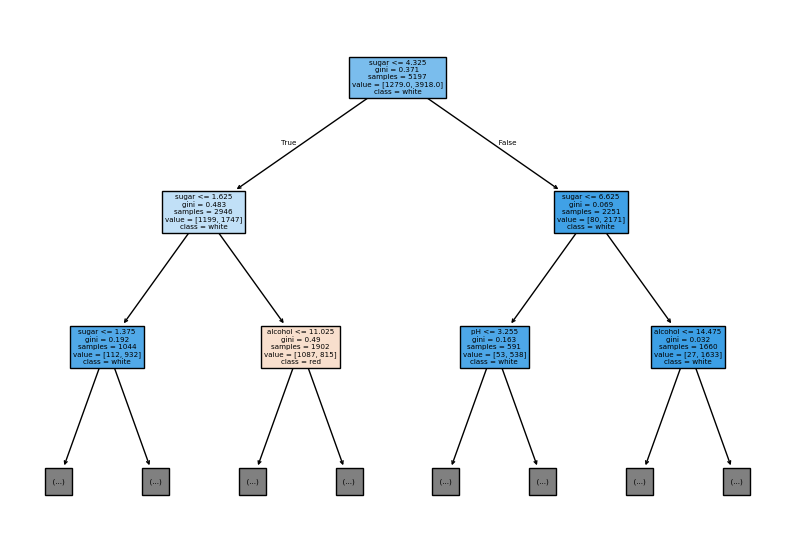

In [7]:
# 트리 구조 시각화
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 7))
plot_tree(
    df_clf,
    max_depth=2,    # 너무 깊으면 확인이 복잡하므로 일부만 표시
    filled=True,    # 클래스 색에 따라 색상 변경
    feature_names=wine_df.columns[:-1],
    class_names=['red','white']
)
plt.savefig('dr_tree_wine.png', dpi=300, bbox_inches='tight')
plt.show()

## 정보이득 Information Gain | 불순도 Impurity

결정 트리는 **가장 잘 나눠지는 질문** 을 고른다. 여기서 잘 나눠진다는 말은, 분할한 뒤 각 그룹이 덜 섞이게 된다는 뜻이다.

쉽게 말하면
- 한쪽에는 red가 거의 몰리고
- 다른 쪽에는 white가 거의 몰리면

좋은 분할이라고 볼 수 있다.

이때 **얼마나 섞여 있는가** 를 수치로 나타낸 것이 불순도(impurity)이다.
대표적인 기준이 다음 2가지이다.
- 지니 불순도(Gini impurity)
- 엔트로피(Entropy)

또한, 분할 전보다 분할 후가 얼마나 더 깔끔해졌는지를 정보이득(information gain)이라고 부른다.
즉,
- 불순도가 많이 줄어들수록
- 정보이득이 크다고 볼 수 있다.

결정 트리는 매 단계마다 이런 기준을 이용해 가장 좋은 질문을 자동으로 선택한다.

### 지니 불순도 계산

지니 불순도(Gini impurity)는 데이터가 얼마나 섞여 있는지를 나타내는 값이다.

핵심 해석
- 0에 가까우면: 한 클래스만 거의 모여 있는 상태
- 값이 커질수록: 여러 클래스가 섞여 있는 상태

즉, 지니 불순도가 낮을수록 더 순수한 그룹(pure node)이라고 볼 수 있다.

지니 불순도 공식:

$
\text{Gini} = 1 - (클래스1 비율^2 + 클래스2 비율^2 + ... + 클래스n 비율^2)
$

이진 분류, 다중 분류 모두 같은 아이디어를 사용한다.

예를 들어 어떤 노드에
- red 1279개
- white 3918개

가 있다면, 이 노드의 지니 불순도를 직접 계산할 수 있다.

In [8]:
# 트리노드 최상단의 예시
'''
sugar <= 4.325
gini = 0.371
sample = 5197
value = [1279.0, 3917.0]
'''

1 - ((1279/5197)**2 + (3918/5197)**2)


0.37107315616915937

### 엔트로피 지수

엔트로피(Entropy)도 **얼마나 섞여 있는가**를 재는 기준이다.
지니와 목적은 거의 같고, 계산 방식만 다르다.

엔트로피 공식
$Entropy = -\sum (p_k \cdot \log_2(p_k))$

해석
- 엔트로피가 낮다: 한 클래스 쪽으로 잘 모여 있다.
- 엔트로피가 높다: 여러 클래스가 많이 섞여 있다.

[참고]
- 엔트로피는 **예측이 얼마나 어려운 상태인가** 를 숫자로 표현한 값이다.
- 확률이 비슷하게 섞여 있을수록 (예: 50% / 50%) 무엇이 나올지 알기 어려움 -> 엔트로피가 커진다.
- 한쪽으로 치우칠수록 (예: 90% / 10%) → 대부분 한 클래스이므로 예측이 쉬움 -> 엔트로피가 작아진다.
- 완전히 한 클래스만 있는 경우 (100% / 0%) 더 이상 헷갈릴 것이 없음 -> 엔트로피는 0이다.

로그를 사용하는 이유?
- 확률이 낮은 사건일수록 더 놀라운 정보로 간주한다.
- log는 이런 놀람의 크기를 수치로 표현하는 역할을 한다.
- 여기에 확률을 다시 곱해서, 전체적으로 평균적인 불확실성을 계산한다.

결정 트리는 분할 전후 엔트로피 변화를 보고, 더 깔끔하게 나뉘는 기준을 선택한다.

In [9]:
# criterion = "entropy" 로 변경해서 학습
dt_clf = DecisionTreeClassifier(random_state=42, criterion='entropy', max_depth=5)
dt_clf.fit(X_train, y_train)

# 평가
print(f"학습셋 정확도 : {df_clf.score(X_train, y_train)}")
print(f"평가셋 정확도 : {df_clf.score(X_test, y_test)}")

학습셋 정확도 : 0.9978833942659227
평가셋 정확도 : 0.8653846153846154


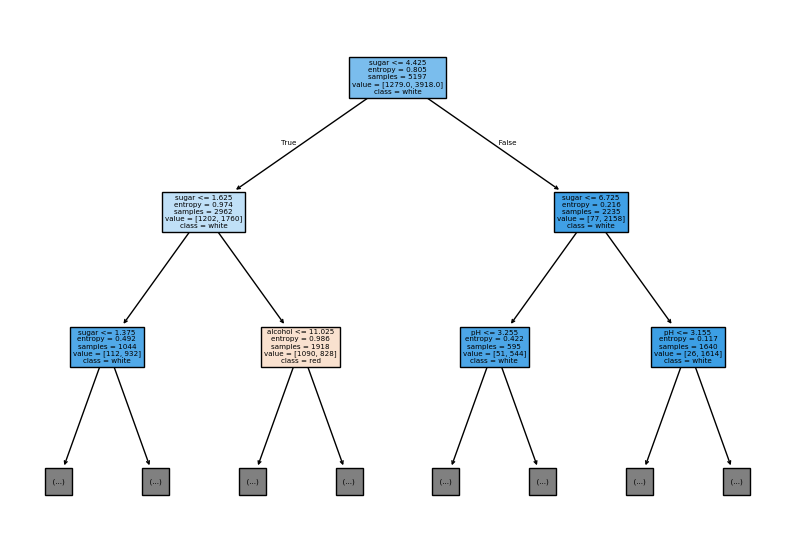

In [11]:
# 트리 구조 시각화
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 7))
plot_tree(
    dt_clf,
    max_depth=2,    # 너무 깊으면 확인이 복잡하므로 일부만 표시
    filled=True,    # 클래스 색에 따라 색상 변경
    feature_names=wine_df.columns[:-1],
    class_names=['red','white']
)
plt.savefig('dr_tree_wine_entropy.png', dpi=300, bbox_inches='tight')
plt.show()

## 가지치기 Pruning

결정 트리는 깊어질수록 학습 데이터에 지나치게 맞춰질 수 있다.
이런 현상을 과적합(overfitting)이라고 한다.

가지치기(pruning)는 불필요하게 복잡한 가지를 줄여서
트리를 너무 세세하게 자라지 못하게 하는 방법이다.

자주 쓰는 방법
- 사전 가지치기(pre-pruning): 트리를 만드는 도중 미리 제한을 건다.
  - `max_depth`
  - `min_samples_split`
  - `min_samples_leaf`
- 사후 가지치기(post-pruning): 일단 만든 뒤 불필요한 가지를 줄인다.
  - `ccp_alpha`

유의할 점
- 트리를 깊게 만들수록 학습 정확도는 잘 오를 수 있다.
- 하지만 평가 정확도는 오히려 떨어질 수 있다.
- 그래서 **적당한 복잡도** 를 찾는 것이 중요하다.

In [12]:
# max_depth : 트리 최대 깊이 제한
df_clf1 = DecisionTreeClassifier(random_state=42)
df_clf1.fit(X_train, y_train)

df_clf2 = DecisionTreeClassifier(random_state=42, max_depth=5)
df_clf2.fit(X_train, y_train)

print('가지치기 적용 안함')
print(f"학습셋 정확도 : {df_clf1.score(X_train, y_train)}")
print(f"평가셋 정확도 : {df_clf1.score(X_test, y_test)}")

print('가지치기 적용함')
print(f"학습셋 정확도 : {df_clf2.score(X_train, y_train)}")
print(f"평가셋 정확도 : {df_clf2.score(X_test, y_test)}")

가지치기 적용 안함
학습셋 정확도 : 0.9978833942659227
평가셋 정확도 : 0.8653846153846154
가지치기 적용함
학습셋 정확도 : 0.8718491437367712
평가셋 정확도 : 0.8576923076923076


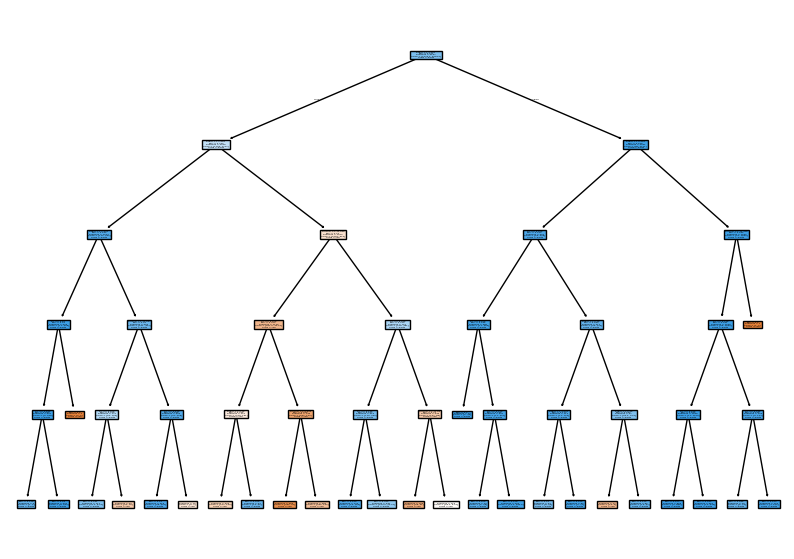

In [14]:
# 트리 구조 시각화
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 7))
plot_tree(
    df_clf2,
    filled=True,    # 클래스 색에 따라 색상 변경
    feature_names=wine_df.columns[:-1],
    class_names=['red','white']
)
plt.show()

In [16]:
# min_sample_split : 어떤 노드를 분할하려면 몇 개의 샘플이 있어야 하는가
# 값이 크면 너무 잘게 쪼개지는 것을 방지할 수 있다.
dt_clf1 = DecisionTreeClassifier(random_state=42)
dt_clf1.fit(X_train, y_train)

dt_clf2 = DecisionTreeClassifier(random_state=42, min_samples_split=170)
dt_clf2.fit(X_train, y_train)

print('가지치기 적용 안함')
print(f"학습셋 정확도 : {df_clf1.score(X_train, y_train)}")
print(f"평가셋 정확도 : {df_clf1.score(X_test, y_test)}")

print('가지치기 적용함')
print(f"학습셋 정확도 : {df_clf2.score(X_train, y_train)}")
print(f"평가셋 정확도 : {df_clf2.score(X_test, y_test)}")

가지치기 적용 안함
학습셋 정확도 : 0.9978833942659227
평가셋 정확도 : 0.8653846153846154
가지치기 적용함
학습셋 정확도 : 0.8718491437367712
평가셋 정확도 : 0.8576923076923076


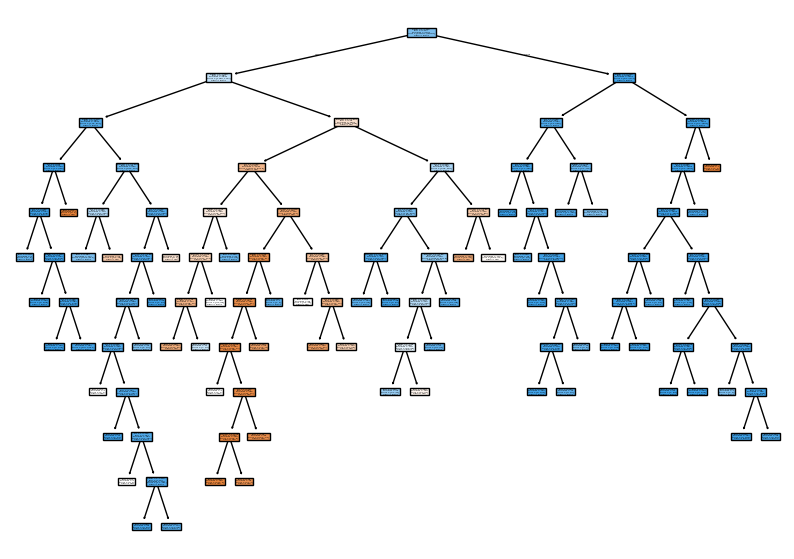

In [17]:
# 트리 구조 시각화
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 7))
plot_tree(
    dt_clf2,
    filled=True,    # 클래스 색에 따라 색상 변경
    feature_names=wine_df.columns[:-1],
    class_names=['red','white']
)
plt.show()

In [18]:
# min_sample_leaf : 리프노드가 되기 위한 최소 샘플 수
# 분할 후 만들어지는 자식 노드가 모두 이 값 이상이어야 한다.
df_clf1 = DecisionTreeClassifier(random_state=42)
df_clf1.fit(X_train, y_train)

df_clf2 = DecisionTreeClassifier(random_state=42, min_samples_leaf=50)
df_clf2.fit(X_train, y_train)

print('가지치기 적용 안함')
print(f"학습셋 정확도 : {df_clf1.score(X_train, y_train)}")
print(f"평가셋 정확도 : {df_clf1.score(X_test, y_test)}")

print('가지치기 적용함')
print(f"학습셋 정확도 : {df_clf2.score(X_train, y_train)}")
print(f"평가셋 정확도 : {df_clf2.score(X_test, y_test)}")

가지치기 적용 안함
학습셋 정확도 : 0.9978833942659227
평가셋 정확도 : 0.8653846153846154
가지치기 적용함
학습셋 정확도 : 0.8781989609390033
평가셋 정확도 : 0.86


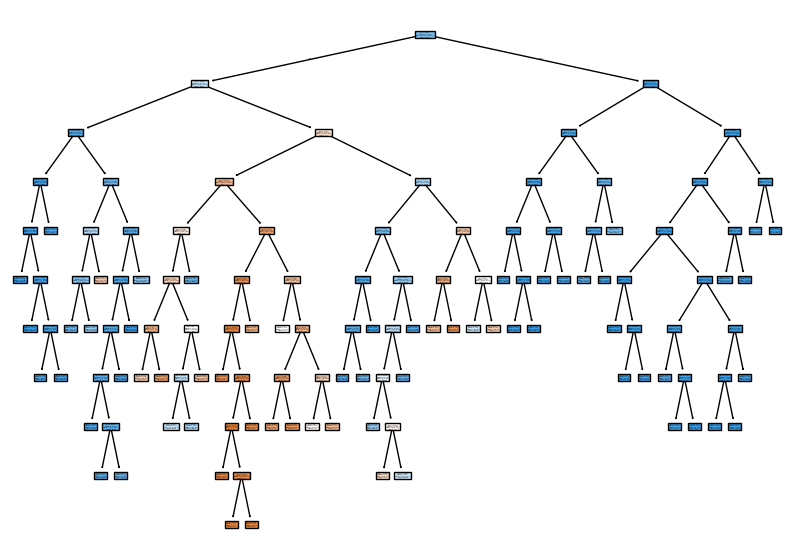

In [19]:
# 트리 구조 시각화
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 7))
plot_tree(
    df_clf2,
    filled=True,    # 클래스 색에 따라 색상 변경
    feature_names=wine_df.columns[:-1],
    class_names=['red','white']
)
plt.show()

## 특성 중요도 Feature Importance

결정 트리는 분할에 많이 기여한 특성일수록 중요도를 높게 준다.
이를 특성 중요도(feature importance)라고 한다.

쉽게 말하면,
**이 트리가 어떤 변수를 더 자주, 더 중요하게 사용했는가?**
를 수치로 보여주는 것이다.

주의할 점
- 중요도가 높다고 해서 반드시 인과관계가 있다는 뜻은 아니다.
- 다만 모델이 예측할 때 상대적으로 많이 참고한 특성이라고 해석할 수 있다.

In [20]:
# 각 특성의 중요도 확인
print(wine_df.columns[:-1])
print(dt_clf.feature_importances_)

Index(['alcohol', 'sugar', 'pH'], dtype='str')
[0.12596766 0.74060754 0.13342481]


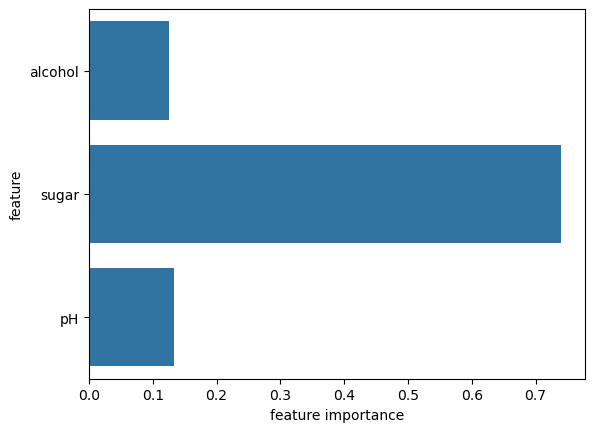

In [21]:
# 특성 중요도 시각화
sns.barplot(
    x = dt_clf.feature_importances_,
    y = wine_df.columns[:-1]
)
plt.xlabel('feature importance')
plt.ylabel('feature')
plt.show()

## 실습: iris

1. 하이퍼파라미터 최적화
2. 결정 트리 학습
3. 트리 시각화
4. 어떤 기준으로 분할되는지 해석
5. 가장 중요한 특성이 무엇인지 확인

In [22]:
# 데이터 로드
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

# 학습용 / 평가용 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [ ]:
# 하이퍼파라미터 최적화
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion' : ['gini', 'entropy'],
    'max_depth' : [3, 4, 5],
    'min_samples_split' : [2, 3],
    'min_samples_leaf' : [1, 2]
}

model = DecisionTreeClassifier(random_state=42)

grid = GridSearchCV(model,
                    param_grid=param_grid,
                    cv=3,
                    scoring='accuracy',
                    refit=True)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [42]:
dt_iris = DecisionTreeClassifier(random_state=42, criterion='gini', max_depth=3, min_samples_leaf=1, min_samples_split=2)
dt_iris.fit(X_train, y_train)

print("파라미터 적용 학습셋 점수 : ", dt_iris.score(X_train, y_train))
print("파라미터 적용 평가셋 점수 : ", dt_iris.score(X_test, y_test))

파라미터 적용 학습셋 점수 :  0.9833333333333333
파라미터 적용 평가셋 점수 :  0.9666666666666667


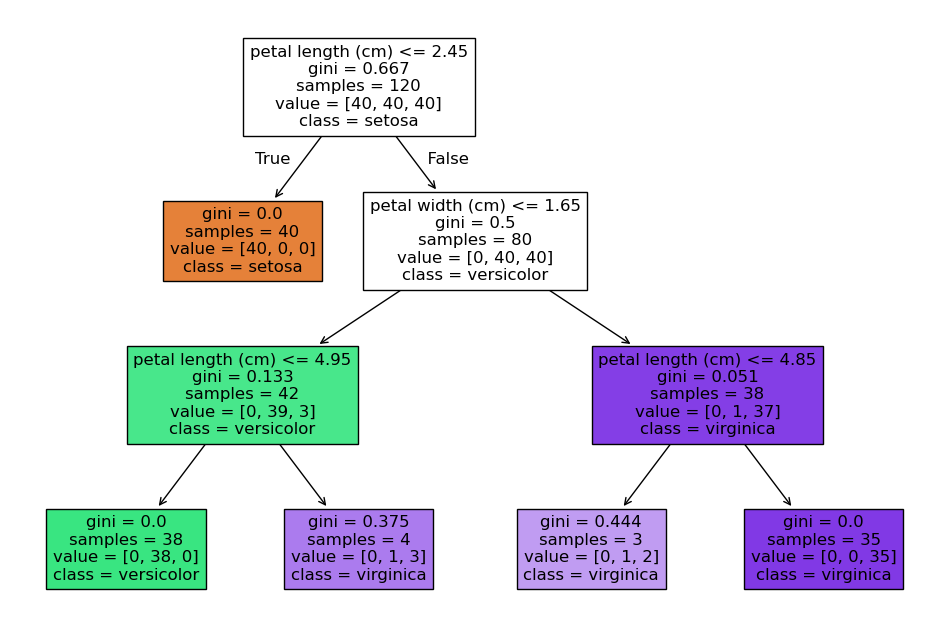

In [43]:
plt.figure(figsize=(12,8))
plot_tree(
    dt_iris,
    filled=True,
    feature_names=iris['feature_names'],
    class_names=iris['target_names']
)
plt.show()

In [44]:
print(iris['feature_names'])
print(dt_iris.feature_importances_)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[0.         0.         0.57907728 0.42092272]


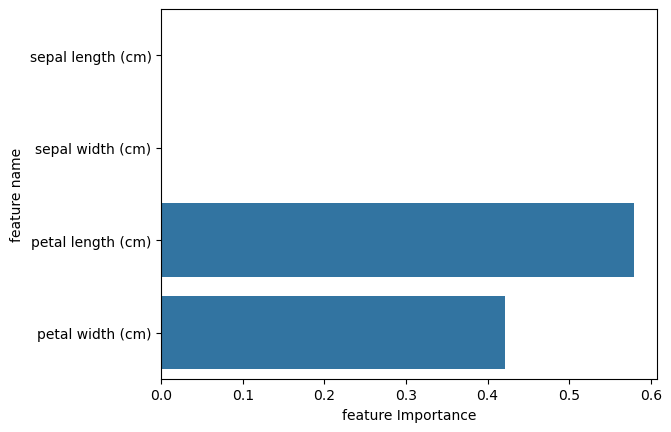

In [46]:
sns.barplot(
    x = dt_iris.feature_importances_,
    y = iris.feature_names,
)
plt.xlabel('feature Importance')
plt.ylabel('feature name')
plt.show()